# Tuning and Model Evaluation

## Used libraries

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, LearningCurveDisplay, learning_curve, ValidationCurveDisplay, validation_curve
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel, f_classif

C:\Users\Hassan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data

In [3]:
train = pd.read_parquet('../train_extended.parquet')
test = pd.read_parquet('../test_extended.parquet')

x_train, y_train = train.drop('RET', axis=1), train['RET']

## Feature pre-selection

Below the differents selection of feature done on the ``notebook_feature_selection.ipynb``

In [4]:
fi = pd.read_hdf('features_statistics.h5', key='fi')
mi = pd.read_hdf('features_statistics.h5', key='mi')
fwd_corr = pd.read_hdf('features_statistics.h5', key='fwd_corr')
# shapval = pd.read_hdf('features_statistics.h5', key='shap_values')
features = pd.read_hdf('features_statistics.h5', key='features_rfe').tolist()

Here I'm testing various combinations of subsets to find the best recipe.

In [5]:
len(features), features

(35,
 ['Std_RET_4D',
  'Std_RET_20D',
  'Std_RET_12D',
  'RET_3_INDUSTRY_GROUP_DATE_min',
  'RET_1_STOCK_std',
  'RET_4_STOCK_std',
  'RET_2_STOCK_std',
  'RET_1_SECTOR_DATE_mean',
  'RET_1_DATE_skew',
  'RET_4_INDUSTRY_GROUP_DATE_max',
  'VOLUME_5_DATE_std',
  'RET_10_SECTOR_DATE_Momentum',
  'RET_SECTOR_DATE_VOLATILITY_10',
  'RET_5_DATE_mean',
  'RSI_15_SECTOR_DATE',
  'VOLUME_3_STOCK_min',
  'RET_1_SUB_INDUSTRY_DATE_RANK',
  'RET_5_SECTOR_DATE_Momentum',
  'RET_5_INDUSTRY_GROUP_DATE_min',
  'VOLUME_1',
  'VOLATILITY_RET',
  'Range_RET_20D',
  'RET_SECTOR_DATE_VOLATILITY_5',
  'ADL_15_SECTOR_DATE',
  'RET_5_SECTOR_DATE_mean',
  'MA_RET',
  'VOV_SECTOR_DATE_std',
  'VOLUME_1_SECTOR_DATE_NEUTRAL',
  'RSI_20_SECTOR_DATE',
  'RET_3_INDUSTRY_DATE_mean',
  'RET_1_INDUSTRY_GROUP_DATE_RANK',
  'RET_1_SUB_INDUSTRY_DATE_NEUTRAL',
  'RET_1_SECTOR_DATE_NEUTRAL',
  'RET_3_INDUSTRY_GROUP_DATE_mean',
  'RET_1_INDUSTRY_GROUP_DATE_NEUTRAL'])

## Fine-Tuning

In [ ]:
# optuna hyperparameter optimization

def objective(trial):
    # Define the hyperparameters to optimize
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
    }
    # Define the model
    clf =  RandomForestClassifier(**params, n_jobs=-1)
    cv = KFold(n_splits=3, shuffle=True)
    # Define the score
    score = cross_val_score(clf, x_train[features], y_train, cv=cv, scoring='accuracy').mean()
    return score

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
 
# Print the best set of hyperparameters
print('Best hyperparameters: ', study.best_params)
# Print the corresponding performance
print('Best performance: ', study.best_value)

### Validation and Learning Curve

In [ ]:
# Validation and learning curve plot 

# Define the model with the best hyperparameters
clf = RandomForestClassifier(**study.best_params, n_jobs=-1, verbose=1)
# Define the learning curve
train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, x_train[features], y_train, cv=3, train_sizes=np.linspace(0.1, 1.0, 3), return_times=True)


In [ ]:

# Plot the learning curve
fig, ax = plt.subplots()
ax.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
ax.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
ax.set_xlabel('Training examples')
ax.set_ylabel('Score')
ax.legend()
plt.show()


In [ ]:
clf = RandomForestClassifier(max_depth=8, n_jobs=-1, verbose=1)

# Define the validation curve
param_range = np.arange(400, 1000, 100)
train_scores, test_scores = validation_curve(clf, x_train[features], y_train, param_name='n_estimators', param_range=param_range, cv=3)

# Plot the validation curve
fig, ax = plt.subplots()
ax.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
ax.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
ax.set_xlabel('Number of trees')
ax.set_ylabel('Score')
ax.legend()
plt.show()



## Model and local score

A Random Forest (RF) model is chosen for the Benchmark. We consider a large number of tree with a quiet small depth. The missing values are simply filled with 0. A KFold is done on the dates (using `DATE`) for a local scoring of the model. 

**Ideas of improvements**: Tune the RF hyperparameters, deal with the missing values, change the features, consider another model, ...

In [9]:
# Final model

X_train = train[features]

# Define the model with the best hyperparameters
# A quiet large number of trees with low depth to prevent overfits

tuned_model = RandomForestClassifier(n_estimators=800, max_depth=9, n_jobs=-1)


train_dates = train['DATE'].unique()
test_dates = test['DATE'].unique()

n_splits = 4
scores = []
models = []

splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True).split(train_dates) # Generates the splits of the indexes to use as train / test

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = train['DATE'].isin(local_train_dates)
    local_test_ids = train['DATE'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids]
    y_local_train = y_train.loc[local_train_ids]
    X_local_test = X_train.loc[local_test_ids]
    y_local_test = y_train.loc[local_test_ids]

    model = clone(tuned_model)
    model.fit(X_local_train, y_local_train.values.reshape(-1))

    y_local_pred = model.predict_proba(X_local_test)[:, 1]
    
    sub = train.loc[local_test_ids].copy()
    sub['pred'] = y_local_pred
    y_local_pred = sub.groupby('DATE')['pred'].transform(lambda x: x > x.median()).values

    models.append(model)
    score = accuracy_score(y_local_test, y_local_pred)
    scores.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores)*100
std = np.std(scores)*100
u = (mean + std)
l = (mean - std)
print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')

Fold 1 - Accuracy: 51.72%
Fold 2 - Accuracy: 51.79%
Fold 3 - Accuracy: 53.30%
Fold 4 - Accuracy: 53.19%
Accuracy: 52.50% [51.75 ; 53.24] (+- 0.74)


In [ ]:
# cross validation score with predict built-in method to compare with the previous prediction method
score = cross_val_score(tuned_model, X_train, y_train, cv=4, scoring='accuracy', n_jobs=-1, verbose=1)

print("Cross-validation score with predict built-in method")
for i in range(len(score)):
    print(f'Fold {i+1} - Accuracy: {score[i]*100:.2f}%')
print(f'Accuracy: {np.mean(score)*100:.2f}% (+- {np.std(score)*100:.2f})')

Feature importances of the 35 features


<Axes: >

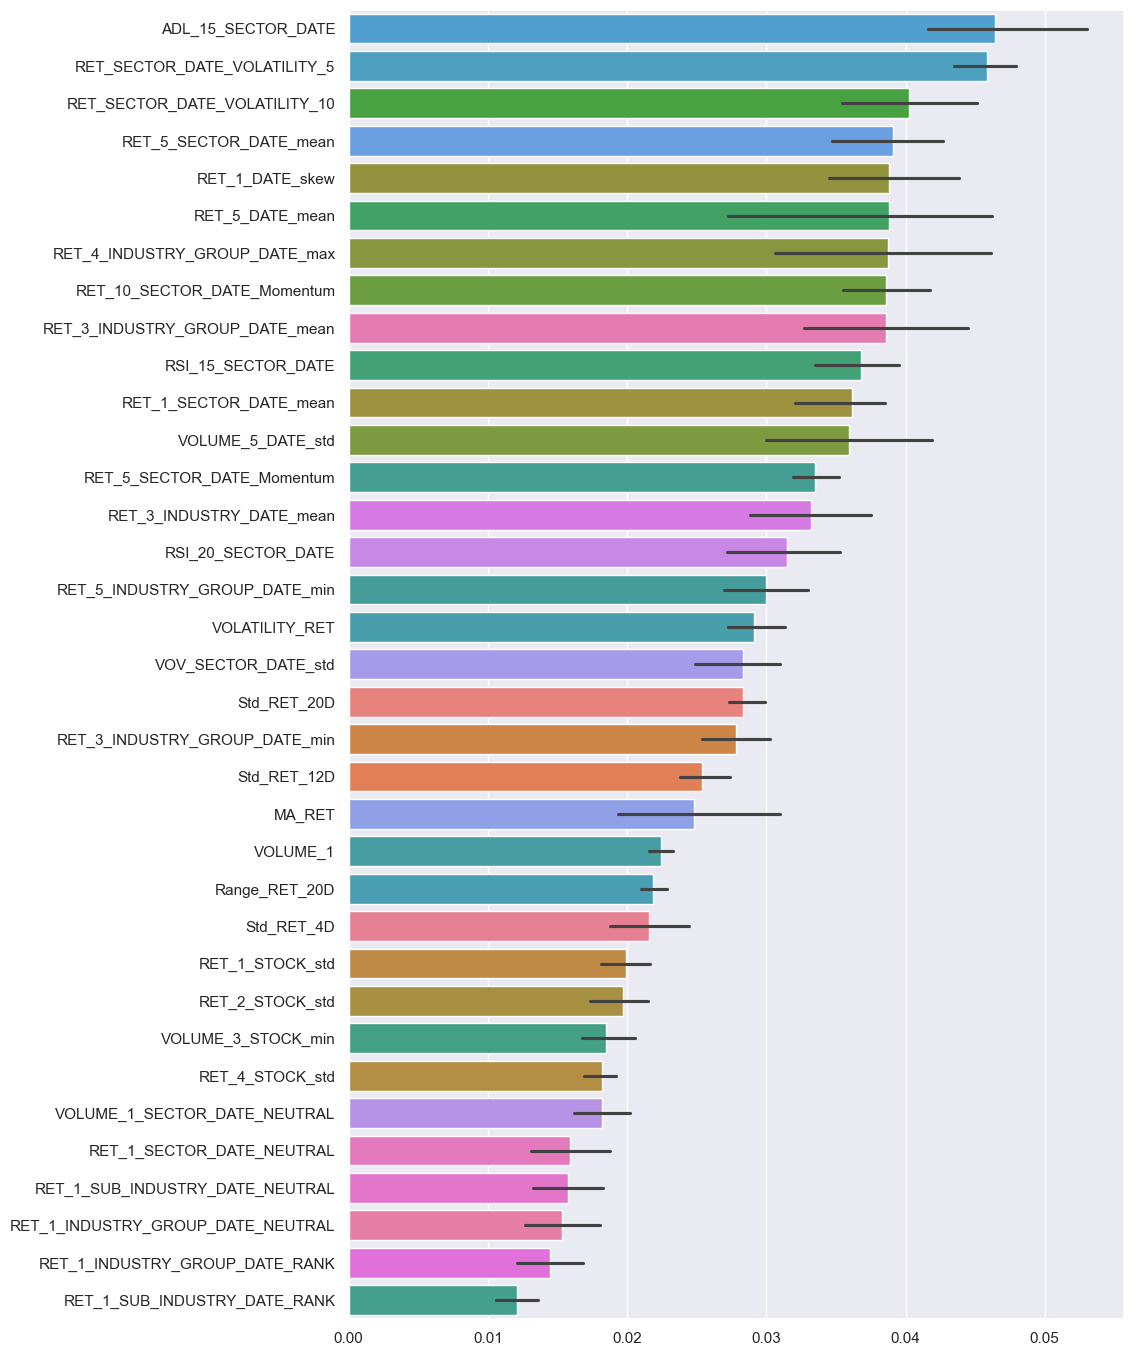

In [10]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)
print(f"Feature importances of the {len(features)} features")
sns.set(rc={'figure.figsize':(10,len(features)//2)})
sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index )

## Generate the submission

The same parameters of the RF model are considered. With that we build a new RF model on the entire `train` dataset. The predictions are saved in a `.csv` file.

In [11]:
target = 'RET'
X_test = test[features]

model = clone(tuned_model)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

sub = test.copy()
sub['pred'] = y_pred
y_pred = sub.groupby('DATE')['pred'].transform(
    lambda x: x > x.median()).values

submission = pd.Series(y_pred)
submission.index = test.index
submission.name = target

submission.to_csv('submission.csv', index=True, header=True)

## Draft Zone

### Defining our ML Pipeline and the GridSearchCV procedure
- Throug a GridSearchCV we aim to compare the performance of different Imputations methods and Feature Selections
- For that we create a pipeline to embbed all the successive steps of the data transformation in one estimator
- Warning to use Catboost in a pipeline : 
    - https://medium.com/analytics-vidhya/combining-scikit-learn-pipelines-with-catboost-and-dask-part-2-9240242966a7
    - https://stackoverflow.com/questions/56742441/



In [ ]:

model = Pipeline([
    ('feature_selection', 'passthrough'),
    ('classify', 'passthrough')
])

# Define the parameter grid for GridSearchCV
param_grid = [
    {
        'feature_selection': [SelectFromModel(RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },

    {
        'feature_selection': [SelectFromModel(CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=50, task_type="GPU", devices='0', verbose=0))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },
    
    {
        'feature_selection': [SelectKBest()],
        'feature_selection__score_func': [mutual_info_classif, f_classif],
        'feature_selection__k': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)],
    }
]

# define the GridSearchCV
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', verbose=3, n_jobs=1, error_score='raise')

# fit the GridSearchCV
grid.fit(x_train, y_train)

# get the parameters of models sorted by ranked score of accuracy
results = pd.DataFrame(grid.cv_results_)
results.sort_values(by='rank_test_score', inplace=True)
results